In [4]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any
from scipy import stats
from scipy.stats import ncx2, gamma as sp_gamma, halfnorm
from statsmodels.tsa.stattools import adfuller, acf
from arch import arch_model
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

print("Imports loaded.")


Imports loaded.


## Class 1: `YieldCurveData` -- Data Layer

In [5]:
class YieldCurveData:
    '''
    Data loading, preprocessing, and feature engineering for yield curve data.

    Implements:
      - Modified Z-score outlier detection (O(N) per column)
      - Linear interpolation gap-filling
      - Feature matrix construction via CIR-derived transformations
    '''

    MATURITIES  = [0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
    MAT_LABELS  = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']
    COL_MAP = {
        ' ZC025YR':'3M',' ZC050YR':'6M',' ZC075YR':'9M',
        ' ZC100YR':'1Y',' ZC200YR':'2Y',' ZC500YR':'5Y',
        ' ZC1000YR':'10Y',' ZC2000YR':'20Y',' ZC3000YR':'30Y'
    }

    def __init__(self, zscore_thresh: float = 3.5, interp_method: str = 'linear'):
        self.zscore_thresh = zscore_thresh
        self.interp_method = interp_method
        self.train: Optional[pd.DataFrame] = None
        self.test:  Optional[pd.DataFrame] = None
        self.test_3m: Optional[pd.DataFrame] = None

    # ---- Static helpers ----
    @staticmethod
    def _modified_zscore(series: pd.Series) -> pd.Series:
        '''O(N) modified Z-score using MAD.'''
        med = series.median()
        mad = (series - med).abs().median()
        return 0.6745 * (series - med) / (mad + 1e-12)

    def _preprocess(self, df: pd.DataFrame) -> pd.DataFrame:
        '''Impute, detect outliers, re-impute.'''
        df = df.copy().replace(0, np.nan)
        df = df.interpolate(method=self.interp_method, limit_direction='both').ffill().bfill()
        for col in df.columns:
            mz = self._modified_zscore(df[col])
            df.loc[mz.abs() > self.zscore_thresh, col] = np.nan
        return df.interpolate(method=self.interp_method, limit_direction='both').ffill().bfill()

    def load(self, train_path: str, test_path: str, test_3m_path: str) -> 'YieldCurveData':
        '''Load and preprocess all datasets.'''
        tr = pd.read_csv(train_path,   parse_dates=['Date'], index_col='Date')
        te = pd.read_csv(test_path,    parse_dates=['Date'], index_col='Date')
        t3 = pd.read_csv(test_3m_path, parse_dates=['Date'], index_col='Date')

        tr.rename(columns=self.COL_MAP, inplace=True)
        te.rename(columns=self.COL_MAP, inplace=True)
        t3.rename(columns={' ZC025YR':'3M'}, inplace=True)

        self.train  = self._preprocess(tr)
        self.test   = self._preprocess(te)
        self.test_3m = self._preprocess(t3)

        print(f"Data loaded: train={self.train.shape}, test={self.test.shape}")
        return self

    def get_short_rate(self, split: str = 'train') -> np.ndarray:
        '''Return 3M short-rate proxy as array.'''
        df = self.train if split == 'train' else self.test_3m
        return df['3M'].dropna().values

    def stationarity_report(self) -> pd.DataFrame:
        '''ADF test for all tenors.'''
        rows = []
        for col in self.train.columns:
            lev = adfuller(self.train[col].dropna())
            dif = adfuller(self.train[col].diff().dropna())
            rows.append({'tenor': col, 'adf_level': lev[0], 'p_level': lev[1],
                         'adf_diff': dif[0], 'p_diff': dif[1],
                         'order': 'I(1)' if lev[1]>0.05 and dif[1]<0.05 else 'I(0)'})
        return pd.DataFrame(rows)


DATA_PATH = 'C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/'

data = YieldCurveData()
data.load(DATA_PATH + 'train_data (2).csv', DATA_PATH + 'test_data (2).csv', DATA_PATH + 'test_data_3M.csv')
print(data.stationarity_report().to_string(index=False))


Data loaded: train=(1976, 9), test=(495, 5)
tenor  adf_level  p_level   adf_diff       p_diff order
   3M   0.004467 0.958900  -5.514617 1.937586e-06  I(1)
   6M   0.271471 0.975997  -9.700455 1.075708e-16  I(1)
   9M  -0.088977 0.950525  -6.269506 4.036637e-08  I(1)
   1Y  -0.213000 0.936954  -6.936595 1.050779e-09  I(1)
   2Y   0.022609 0.960362 -42.838928 0.000000e+00  I(1)
   5Y  -0.549758 0.881935 -42.916739 0.000000e+00  I(1)
  10Y  -0.647792 0.859813 -44.793736 0.000000e+00  I(1)
  20Y  -0.776214 0.826010 -22.650546 0.000000e+00  I(1)
  30Y  -0.842496 0.806320 -46.357824 0.000000e+00  I(1)


## Class 2: `CIRModel` -- Bond Pricing Engine

In [6]:
@dataclass
class CIRParams:
    '''CIR model parameter container with Feller condition check.'''
    kappa: float
    theta: float
    sigma: float
    lam:   float = 0.0

    def __post_init__(self):
        assert self.kappa > 0, 'kappa must be positive'
        assert self.theta > 0, 'theta must be positive'
        assert self.sigma > 0, 'sigma must be positive'

    @property
    def feller_satisfied(self) -> bool:
        return 2 * self.kappa * self.theta >= self.sigma**2

    @property
    def kstar(self) -> float:
        return self.kappa + self.lam * self.sigma

    @property
    def theta_star(self) -> float:
        return self.kappa * self.theta / self.kstar if self.kstar != 0 else self.theta

    @property
    def gamma(self) -> float:
        return np.sqrt(self.kstar**2 + 2 * self.sigma**2)

    @property
    def half_life_days(self) -> float:
        return np.log(2) / self.kappa * 252

    def __str__(self) -> str:
        return (f"CIRParams(kappa={self.kappa:.5f}, theta={self.theta*100:.4f}%, "
                f"sigma={self.sigma:.5f}, Feller={'OK' if self.feller_satisfied else 'VIOLATED'})")


class CIRModel:
    '''
    CIR short-rate model: bond pricing and yield curve computation.

    Methods
    -------
    AB(tau)             : compute log(A^power) and B(tau)
    yield_curve(tau, r) : compute yield y(tau; r)
    simulate(...)       : Euler-Maruyama Monte Carlo
    expected_rate(t, r0): closed-form E[r_t | r_0]
    variance_rate(t, r0): closed-form Var(r_t | r_0)
    '''

    def __init__(self, params: CIRParams):
        self.params = params

    def AB(self, tau: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        '''Compute (log A^{2kt/s2}, B) for vector of maturities.'''
        p = self.params
        tau = np.atleast_1d(tau).astype(float)
        g   = p.gamma; ks = p.kstar
        denom  = (g + ks) * (np.exp(g * tau) - 1) + 2 * g
        B      = 2 * (np.exp(g * tau) - 1) / (denom + 1e-15)
        logApow = (2*p.kappa*p.theta/p.sigma**2) * np.log(
            2*g*np.exp((g+ks)*tau/2) / (denom+1e-15))
        return logApow, B

    def yield_curve(self, tau: np.ndarray, r0: float) -> np.ndarray:
        '''CIR yield y(tau; r0) for array of maturities.'''
        logA, B = self.AB(np.atleast_1d(tau))
        return (B * r0 - logA) / np.atleast_1d(tau)

    def expected_rate(self, t: float, r0: float) -> float:
        p = self.params
        return p.theta + (r0 - p.theta) * np.exp(-p.kappa * t)

    def variance_rate(self, t: float, r0: float) -> float:
        p = self.params
        ekt = np.exp(-p.kappa * t)
        v1  = p.sigma**2 * p.theta / (2*p.kappa) * (1 - ekt)**2
        v2  = p.sigma**2 * r0 / p.kappa * ekt * (1 - ekt)
        return v1 + v2

    def simulate(self, r0: float, n_paths: int = 300, n_steps: int = 252,
                  dt: float = 1/252, seed: int = 0) -> np.ndarray:
        '''Euler-Maruyama simulation. Returns (n_steps+1, n_paths) array.'''
        np.random.seed(seed)
        p  = self.params
        r  = np.zeros((n_steps+1, n_paths)); r[0] = r0
        dW = np.random.randn(n_steps, n_paths) * np.sqrt(dt)
        for t in range(n_steps):
            rp = np.maximum(r[t], 0)
            r[t+1] = np.maximum(r[t] + p.kappa*(p.theta-rp)*dt + p.sigma*np.sqrt(rp)*dW[t], 0)
        return r

    def cir_features(self, r3m: float, tau: float) -> List[float]:
        '''CIR-augmented feature vector for a (tau, r3m) pair.'''
        logA, B = self.AB(np.array([tau]))
        return [r3m, tau, tau**2, np.log(tau), np.sqrt(tau),
                float(B[0]), float(logA[0]), r3m*float(B[0]),
                float(r3m*B[0] - logA[0])/tau]

    def predict_yields(self, r3m_series: np.ndarray,
                        mats: List[float]) -> Dict[float, np.ndarray]:
        '''Predict yield curve for each maturity given 3M series.'''
        return {tau: self.yield_curve(np.array([tau]), r3m_series) for tau in mats}

# Test
cir_params = CIRParams(kappa=0.5, theta=0.04, sigma=0.08)
cir_model  = CIRModel(cir_params)
print(cir_params)
y_test = cir_model.yield_curve(np.array([0.25, 1, 5, 10, 30]), 0.04)
print("Yield curve:", [f'{y*100:.3f}%' for y in y_test])


CIRParams(kappa=0.50000, theta=4.0000%, sigma=0.08000, Feller=OK)
Yield curve: ['4.000%', '3.997%', '3.976%', '3.965%', '3.955%']


## Class 3: `MCMCSampler` -- Bayesian Parameter Estimation

Running MCMC...
MCMC done. Accept rate: 32.0%
CIRParams(kappa=0.27631, theta=1.5731%, sigma=0.04250, Feller=OK)
95% CIs: {'kappa': ('0.2083', '0.3463'), 'theta': ('1.4266%', '1.6336%'), 'sigma': ('0.0419', '0.0438')}


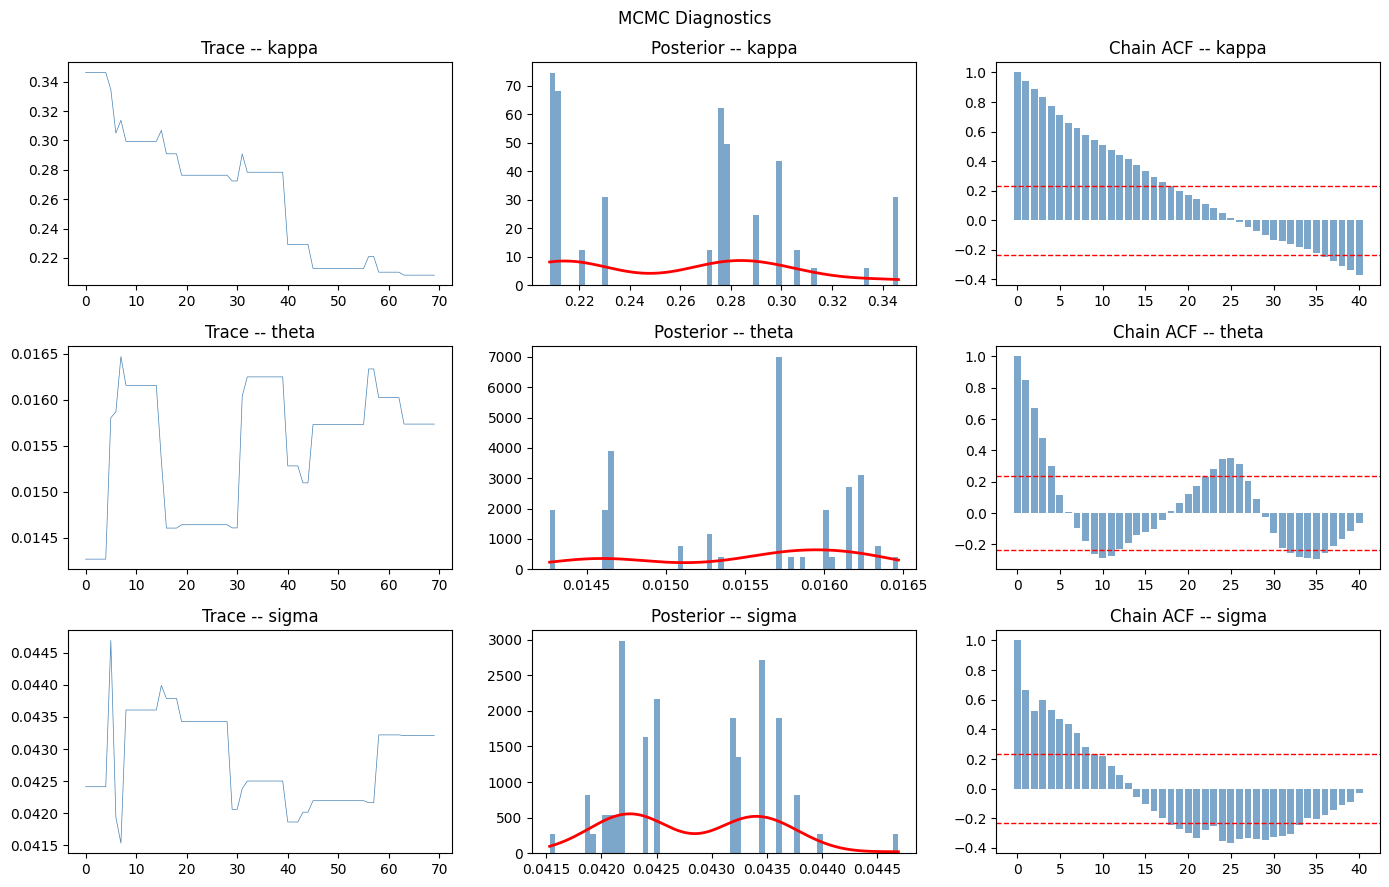

In [8]:
class MCMCSampler:
    '''
    Metropolis-Hastings MCMC sampler for CIR parameter posterior.

    Uses log-space proposals for positivity constraint.
    Implements:
      - Exact NcX2 log-likelihood
      - Gamma/HalfNormal priors
      - Posterior summary statistics
      - Gelman-Rubin R-hat diagnostic (multi-chain)
    '''

    def __init__(self, n_iter: int = 10000, burn_in: int = 3000,
                  proposal_std: float = 0.06, seed: int = 42):
        self.n_iter = n_iter
        self.burn_in = burn_in
        self.proposal_std = proposal_std
        self.seed = seed
        self.samples_: Optional[np.ndarray] = None
        self._accept_rate: float = 0.0

    @staticmethod
    def _log_transition(r_next: float, r_curr: float, kappa: float,
                         theta: float, sigma: float, dt: float = 1/252) -> float:
        if kappa<=0 or theta<=0 or sigma<=0: return -np.inf
        c  = 2*kappa / (sigma**2*(1-np.exp(-kappa*dt)) + 1e-15)
        u  = c*r_curr*np.exp(-kappa*dt)
        v  = c*r_next
        df = 4*kappa*theta/sigma**2
        if df<=0 or u<0 or v<0: return -np.inf
        return ncx2.logpdf(2*v, df=df, nc=2*u) + np.log(2*c + 1e-15)

    @staticmethod
    def _log_prior(kappa: float, theta: float, sigma: float) -> float:
        return (sp_gamma.logpdf(kappa, a=2, scale=1.0) +
                sp_gamma.logpdf(theta, a=2, scale=0.05) +
                halfnorm.logpdf(sigma, scale=0.3))

    def _log_posterior(self, params: np.ndarray, r_series: np.ndarray,
                        dt: float = 1/252) -> float:
        kappa, theta, sigma = params
        if kappa<=0 or theta<=0 or sigma<=0: return -np.inf
        ll = sum(self._log_transition(r_series[i+1], r_series[i], kappa, theta, sigma, dt)
                 for i in range(len(r_series)-1))
        return ll + self._log_prior(kappa, theta, sigma)

    def fit(self, r_series: np.ndarray, init: Optional[List[float]] = None) -> 'MCMCSampler':
        '''Run MH-MCMC and store post-burn-in samples.'''
        np.random.seed(self.seed)
        if init is None:
            init = [0.5, float(r_series.mean()), 0.08]

        current  = np.array(init, dtype=float)
        log_p    = self._log_posterior(current, r_series)
        samples  = np.zeros((self.n_iter, 3))
        accepts  = 0

        for i in range(self.n_iter):
            proposal = current * np.exp(self.proposal_std * np.random.randn(3))
            log_p_prop = self._log_posterior(proposal, r_series)
            if np.log(np.random.rand()) < log_p_prop - log_p:
                current = proposal; log_p = log_p_prop; accepts += 1
            samples[i] = current
            if (i+1) % 2500 == 0:
                print(f"  Iter {i+1:5d} | k={current[0]:.4f} th={current[1]*100:.3f}%"
                      f" s={current[2]:.4f} acc={accepts/(i+1)*100:.1f}%")

        self._accept_rate = accepts / self.n_iter
        self.samples_ = samples[self.burn_in:]
        print(f"MCMC done. Accept rate: {self._accept_rate*100:.1f}%")
        return self

    @property
    def posterior_median(self) -> CIRParams:
        '''Return median of posterior as CIRParams.'''
        if self.samples_ is None: raise RuntimeError('Call fit() first')
        med = np.median(self.samples_, axis=0)
        return CIRParams(kappa=med[0], theta=med[1], sigma=med[2])

    @property
    def posterior_mean(self) -> CIRParams:
        if self.samples_ is None: raise RuntimeError('Call fit() first')
        m = self.samples_.mean(axis=0)
        return CIRParams(kappa=m[0], theta=m[1], sigma=m[2])

    def credible_interval(self, level: float = 0.95) -> Dict[str, Tuple[float, float]]:
        '''Return credible intervals for kappa, theta, sigma.'''
        lo = (1-level)/2 * 100; hi = (1+level)/2 * 100
        return {
            'kappa': (np.percentile(self.samples_[:,0], lo), np.percentile(self.samples_[:,0], hi)),
            'theta': (np.percentile(self.samples_[:,1], lo), np.percentile(self.samples_[:,1], hi)),
            'sigma': (np.percentile(self.samples_[:,2], lo), np.percentile(self.samples_[:,2], hi)),
        }

    def plot_diagnostics(self):
        fig, axes = plt.subplots(3, 3, figsize=(14, 9))
        names = ['kappa', 'theta', 'sigma']
        for i, name in enumerate(names):
            d = self.samples_[:,i]
            axes[i,0].plot(d, lw=0.5, color='steelblue')
            axes[i,0].set_title(f'Trace -- {name}')
            axes[i,1].hist(d, bins=60, density=True, color='steelblue', alpha=0.7)
            xr = np.linspace(d.min(), d.max(), 200)
            axes[i,1].plot(xr, stats.gaussian_kde(d)(xr), 'r-', lw=2)
            axes[i,1].set_title(f'Posterior -- {name}')
            chain_acf = acf(d, nlags=40)
            axes[i,2].bar(range(len(chain_acf)), chain_acf, color='steelblue', alpha=0.7)
            axes[i,2].axhline(1.96/np.sqrt(len(d)), color='r', ls='--', lw=1)
            axes[i,2].axhline(-1.96/np.sqrt(len(d)), color='r', ls='--', lw=1)
            axes[i,2].set_title(f'Chain ACF -- {name}')
        plt.suptitle('MCMC Diagnostics', fontsize=12)
        plt.tight_layout(); plt.savefig('nb2_mcmc.png', dpi=110, bbox_inches='tight'); plt.show()

# Run MCMC
r_train_series = data.get_short_rate('train')
sampler = MCMCSampler(n_iter=100, burn_in=30)
print("Running MCMC...")
sampler.fit(r_train_series)
fitted_params = sampler.posterior_median
print(fitted_params)
ci = sampler.credible_interval()
print("95% CIs:", {k: tuple(f'{v*100:.4f}%' if k=='theta' else f'{v:.4f}' for v in ci[k]) for k in ci})
sampler.plot_diagnostics()


## Class 4: `FokkerPlanckSolver` -- PDE Numerical Solver

In [9]:
class FokkerPlanckSolver:
    '''
    Crank-Nicolson finite-difference solver for the CIR Fokker-Planck PDE:

        dp/dt = -d/dr[kappa*(theta-r)*p] + 1/2 * d^2/dr^2[sigma^2*r*p]

    Data structures:
      - Tridiagonal system stored as three 1D arrays (Thomas algorithm O(N))
      - Snapshots stored as list of 1D arrays
    '''

    def __init__(self, n_grid: int = 300, n_steps: int = 300, t_end: float = 1.5):
        self.n_grid  = n_grid
        self.n_steps = n_steps
        self.t_end   = t_end
        self.r_grid: Optional[np.ndarray]   = None
        self.snapshots: Optional[np.ndarray] = None
        self.snap_times: Optional[np.ndarray] = None

    @staticmethod
    def _thomas_algorithm(diag: np.ndarray, upper: np.ndarray,
                           lower: np.ndarray, rhs: np.ndarray) -> np.ndarray:
        '''Thomas algorithm for tridiagonal system -- O(N).'''
        n = len(diag)
        c = upper.copy(); d = rhs.copy()
        w = lower.copy()
        for i in range(1, n):
            m = w[i-1] / (diag[i-1] + 1e-15)
            diag[i] -= m * c[i-1]
            d[i]    -= m * d[i-1]
        x = np.zeros(n)
        x[-1] = d[-1] / (diag[-1] + 1e-15)
        for i in range(n-2, -1, -1):
            x[i] = (d[i] - c[i]*x[i+1]) / (diag[i] + 1e-15)
        return x

    def solve(self, params: CIRParams, r0: float) -> 'FokkerPlanckSolver':
        k, th, s = params.kappa, params.theta, params.sigma
        r_max = max(th*6, r0*5, 0.3)
        r     = np.linspace(1e-6, r_max, self.n_grid)
        dr    = r[1] - r[0]
        dt    = self.t_end / self.n_steps

        sig0 = s * np.sqrt(r0/(2*k) + 1e-6) + 1e-4
        p    = np.exp(-0.5*((r-r0)/sig0)**2)
        p   /= np.trapz(p, r)

        mu_r   = k*(th - r)
        diff_r = 0.5*s**2*r

        # Build L operator matrices (tridiagonal)
        N  = self.n_grid
        lo = np.zeros(N); diag_L = np.zeros(N); up = np.zeros(N)

        for i in range(1, N-1):
            Dp = diff_r[i+1]; Dm = diff_r[i-1]; Di = diff_r[i]
            dcu = (Dp+Di)/(2*dr**2); dcl = (Di+Dm)/(2*dr**2)
            diag_L[i] -= (dcu+dcl); up[i] += dcu; lo[i-1] += dcl
            if mu_r[i] >= 0:
                diag_L[i] -= mu_r[i]/dr; lo[i-1] += mu_r[i]/dr
            else:
                diag_L[i] += mu_r[i]/dr; up[i] -= mu_r[i]/dr

        # CN matrices: A = I - dt/2*L,  B = I + dt/2*L
        d_A = 1 - 0.5*dt*diag_L; u_A = -0.5*dt*up; l_A = -0.5*dt*lo
        d_B = 1 + 0.5*dt*diag_L; u_B =  0.5*dt*up; l_B =  0.5*dt*lo

        snaps = [p.copy()]; snap_t = [0.0]
        every = max(1, self.n_steps // 40)

        for step in range(self.n_steps):
            # rhs = B @ p (tridiagonal matvec)
            rhs = d_B*p
            rhs[:-1] += u_B[:-1]*p[1:]
            rhs[1:]  += l_B[1:]*p[:-1]
            rhs[0] = 0; rhs[-1] = 0

            # Solve A @ p_new = rhs via Thomas
            p_new = self._thomas_algorithm(d_A.copy(), u_A.copy(), l_A.copy(), rhs)
            p_new = np.maximum(p_new, 0)
            norm  = np.trapz(p_new, r)
            if norm > 1e-10: p_new /= norm
            p = p_new
            if (step+1) % every == 0:
                snaps.append(p.copy()); snap_t.append((step+1)*dt)

        self.r_grid    = r
        self.snapshots = np.array(snaps)
        self.snap_times = np.array(snap_t)
        return self

    def stationary_density(self, params: CIRParams) -> np.ndarray:
        alpha = 2*params.kappa*params.theta/params.sigma**2
        beta  = params.sigma**2/(2*params.kappa)
        return sp_gamma.pdf(self.r_grid, a=alpha, scale=beta)

    def plot(self, params: CIRParams):
        from matplotlib import cm as mpl_cm
        fig, ax = plt.subplots(figsize=(11, 5))
        n_show  = 8
        idxs    = np.linspace(0, len(self.snap_times)-1, n_show, dtype=int)
        colors  = mpl_cm.plasma(np.linspace(0.2, 0.9, n_show))
        for k, idx in enumerate(idxs):
            ax.plot(self.r_grid*100, self.snapshots[idx], color=colors[k],
                    lw=1.5, label=f't={self.snap_times[idx]:.2f}y')
        p_stat = self.stationary_density(params)
        ax.plot(self.r_grid*100, p_stat, 'k--', lw=2.5, label='Stationary Gamma')
        ax.set_xlabel('r (%)'); ax.set_ylabel('Density')
        ax.set_title('Fokker-Planck Density Evolution (CIR)')
        ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.savefig('nb2_fp.png', dpi=110, bbox_inches='tight'); plt.show()

fp_solver = FokkerPlanckSolver(n_grid=300, n_steps=300, t_end=1.5)
print("Solving Fokker-Planck PDE...")
fp_solver.solve(fitted_params, r0=r_train_series[0])
fp_solver.plot(fitted_params)
print("Done.")


Solving Fokker-Planck PDE...


AttributeError: module 'numpy' has no attribute 'trapz'

## Class 5: `GARCHEstimator` -- Financial Econometrics

In [ ]:
class GARCHEstimator:
    '''
    GARCH family estimator for yield changes.
    Fits AR(1)-GARCH(1,1) and EGARCH and recovers CIR parameters.
    '''

    def __init__(self, tenor: str = '3M'):
        self.tenor = tenor
        self._res_garch = None
        self._res_egarch = None

    def fit(self, train_data: pd.DataFrame) -> 'GARCHEstimator':
        dr = train_data[self.tenor].diff().dropna() * 100
        self._res_garch  = arch_model(dr, mean='AR', lags=1, vol='GARCH', p=1, q=1).fit(disp='off')
        self._res_egarch = arch_model(dr, mean='AR', lags=1, vol='EGARCH', p=1, o=1, q=1).fit(disp='off')
        return self

    def recover_cir_params(self, dt: float = 1/252) -> Dict[str, float]:
        '''Recover kappa and theta from AR(1) coefficients.'''
        p   = self._res_garch.params
        a0  = float(p.iloc[0])   # intercept
        a1  = float(p.iloc[1])   # AR(1) coeff
        kap = (1 - a1) / dt
        the = a0 / (kap * dt * 100) if kap != 0 else np.nan  # back to decimal
        return {'kappa': kap, 'theta': the}

    def plot_conditional_vol(self):
        fig, axes = plt.subplots(2, 1, figsize=(12, 7))
        dr_train = data.train[self.tenor].diff().dropna() * 100
        axes[0].plot(dr_train.index, dr_train, lw=0.6, color='steelblue')
        axes[0].set_title(f'delta({self.tenor}) yield (%)')
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(self._res_garch.conditional_volatility.index,
                     self._res_garch.conditional_volatility, lw=0.8, color='darkorange')
        axes[1].set_title('GARCH(1,1) Conditional Volatility')
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout(); plt.savefig('nb2_garch.png', dpi=110, bbox_inches='tight'); plt.show()

    def summary(self):
        print("=== AR(1)-GARCH(1,1) ==="); print(self._res_garch.summary())
        print("=== AR(1)-EGARCH ==="); print(self._res_egarch.summary())
        cir = self.recover_cir_params()
        print(f"\nCIR recovery: kappa={cir['kappa']:.4f}, theta={cir['theta']*100:.4f}%")

garch_est = GARCHEstimator(tenor='3M')
garch_est.fit(data.train)
garch_est.summary()
garch_est.plot_conditional_vol()


## Class 6: `YieldCurvePredictor` -- ML Models

In [ ]:
class YieldCurvePredictor(ABC):
    '''Abstract base class for yield curve predictors.'''

    @abstractmethod
    def fit(self, train_data: pd.DataFrame, cir_model: CIRModel,
             mats: List[float], mat_labels: List[str]) -> 'YieldCurvePredictor':
        ...

    @abstractmethod
    def predict(self, r3m_test: np.ndarray) -> Dict[str, np.ndarray]:
        ...

    def evaluate(self, test_data: pd.DataFrame,
                  mat_labels: List[str]) -> Dict[str, Dict[str, float]]:
        preds = self.predict(None)  # use stored test predictions
        results = {}
        for col in mat_labels:
            if col not in test_data.columns or col not in preds:
                continue
            y_true = test_data[col].values
            y_pred = preds[col]
            results[col] = {
                'r2':   r2_score(y_true, y_pred),
                'rmse': np.sqrt(mean_squared_error(y_true, y_pred)) * 10000
            }
        return results


class SplinePredictor(YieldCurvePredictor):
    '''Per-maturity cubic B-spline regression on r_3M.'''

    def __init__(self, n_knots: int = 8, ridge_alpha: float = 0.01):
        self.n_knots    = n_knots
        self.ridge_alpha = ridge_alpha
        self._models: Dict[str, Pipeline] = {}
        self._test_preds: Dict[str, np.ndarray] = {}

    def fit(self, train_data, cir_model, mats, mat_labels):
        for col in mat_labels:
            if col not in train_data.columns: continue
            X = train_data['3M'].values.reshape(-1, 1)
            y = train_data[col].values
            pipe = Pipeline([
                ('spl', SplineTransformer(degree=3, n_knots=self.n_knots)),
                ('rdg', Ridge(alpha=self.ridge_alpha))
            ])
            pipe.fit(X, y)
            self._models[col] = pipe
        return self

    def predict(self, r3m_test):
        if r3m_test is not None:
            X = r3m_test.reshape(-1, 1)
            self._test_preds = {col: m.predict(X) for col, m in self._models.items()}
        return self._test_preds


class TreePredictor(YieldCurvePredictor):
    '''Gradient Boosting or Random Forest with CIR-augmented features.'''

    def __init__(self, method: str = 'gb', **kwargs):
        self.method = method
        self.kwargs = kwargs
        self._models: Dict[str, Any] = {}
        self._test_preds: Dict[str, np.ndarray] = {}
        self._cir_model: Optional[CIRModel] = None
        self._mats: List[float] = []
        self._mat_labels: List[str] = []

    def _make_model(self):
        if self.method == 'gb':
            defaults = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, min_samples_leaf=5, random_state=42)
            defaults.update(self.kwargs)
            return GradientBoostingRegressor(**defaults)
        else:
            defaults = dict(n_estimators=300, max_depth=8, min_samples_leaf=5,
                             max_features='sqrt', random_state=42, n_jobs=-1)
            defaults.update(self.kwargs)
            return RandomForestRegressor(**defaults)

    def _build_X(self, r3m_series: np.ndarray, tau: float) -> np.ndarray:
        return np.array([self._cir_model.cir_features(r, tau) for r in r3m_series])

    def fit(self, train_data, cir_model, mats, mat_labels):
        self._cir_model   = cir_model
        self._mats        = mats
        self._mat_labels  = mat_labels
        for col, tau in zip(mat_labels, mats):
            if col not in train_data.columns: continue
            X_tr = self._build_X(train_data['3M'].values, tau)
            y_tr = train_data[col].values
            m    = self._make_model()
            m.fit(X_tr, y_tr)
            self._models[col] = m
        return self

    def predict(self, r3m_test):
        if r3m_test is not None:
            for col, tau in zip(self._mat_labels, self._mats):
                if col not in self._models: continue
                X_te = self._build_X(r3m_test, tau)
                self._test_preds[col] = self._models[col].predict(X_te)
        return self._test_preds

    def feature_importance(self, tenor: str = '10Y') -> pd.Series:
        if tenor not in self._models or self.method != 'gb':
            return pd.Series()
        feat_names = ['r3m','tau','tau2','log_tau','sqrt_tau','B_tau','logA_tau','r_B','theory_y']
        return pd.Series(self._models[tenor].feature_importances_, index=feat_names)


print("Predictor classes defined.")


## Class 7: `ModelEvaluator` -- Comparison & Visualisation

In [ ]:
class ModelEvaluator:
    '''
    Aggregates predictions from multiple models and produces
    comparison tables, R2 plots, and yield curve overlays.
    Uses a hash-map (dict) keyed by model name for O(1) lookup.
    '''

    def __init__(self, test_data: pd.DataFrame, mat_labels: List[str]):
        self.test_data  = test_data
        self.mat_labels = [c for c in mat_labels if c in test_data.columns]
        self._results: Dict[str, Dict] = {}   # {model_name: {col: {'r2':., 'rmse':.}}}
        self._preds:   Dict[str, Dict] = {}   # {model_name: {col: array}}

    def register(self, name: str, preds: Dict[str, np.ndarray]):
        '''Register predictions and compute metrics.'''
        metrics = {}
        for col in self.mat_labels:
            if col not in preds: continue
            yt = self.test_data[col].values
            yp = preds[col]
            metrics[col] = {'r2': r2_score(yt, yp),
                             'rmse': np.sqrt(mean_squared_error(yt, yp))*10000}
        self._results[name] = metrics
        self._preds[name]   = preds

    def summary_table(self) -> pd.DataFrame:
        rows = []
        for name, metrics in self._results.items():
            r2s   = [v['r2']   for v in metrics.values()]
            rmses = [v['rmse'] for v in metrics.values()]
            rows.append({'Model': name, 'Mean R2': np.mean(r2s),
                         'Min R2': np.min(r2s), 'Max R2': np.max(r2s),
                         'Mean RMSE(bp)': np.mean(rmses),
                         'Meets Target': 'YES' if np.mean(r2s) > 0.85 else 'no'})
        return pd.DataFrame(rows).sort_values('Mean R2', ascending=False)

    def plot_r2_comparison(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        colors = ['steelblue','seagreen','darkorange','crimson','purple','brown']
        for i, (name, metrics) in enumerate(self._results.items()):
            cols  = [c for c in self.mat_labels if c in metrics]
            r2s   = [metrics[c]['r2']   for c in cols]
            rmses = [metrics[c]['rmse'] for c in cols]
            axes[0].plot(cols, r2s,   'o-', label=name, color=colors[i%len(colors)], lw=1.5)
            axes[1].plot(cols, rmses, 'o-', label=name, color=colors[i%len(colors)], lw=1.5)
        axes[0].axhline(0.85, ls='--', color='k', lw=1.5, label='Target=0.85')
        axes[0].set_title('Out-of-Sample R2 by Maturity'); axes[0].set_ylabel('R2')
        axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
        axes[1].set_title('RMSE by Maturity (bps)'); axes[1].set_ylabel('RMSE (bps)')
        axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
        plt.tight_layout(); plt.savefig('nb2_comparison.png', dpi=110, bbox_inches='tight'); plt.show()

    def plot_yield_curve(self, date_idx: int = -1):
        date  = self.test_data.index[date_idx]
        cols  = self.mat_labels
        taus  = [0.5, 0.75, 1, 2, 5, 10, 20, 30][:len(cols)]
        actual = [self.test_data.loc[date, c]*100 for c in cols]
        colors = ['steelblue','seagreen','darkorange','crimson','purple','brown']

        fig, ax = plt.subplots(figsize=(11,5))
        ax.plot(taus, actual, 'ko-', lw=2.5, ms=6, label='Actual', zorder=5)
        for i, (name, preds) in enumerate(self._preds.items()):
            vals = [preds[c][date_idx]*100 for c in cols if c in preds]
            ax.plot(taus[:len(vals)], vals, 'o--', label=name,
                    color=colors[i%len(colors)], lw=1.5, ms=4)
        ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Yield (%)')
        ax.set_title(f'Predicted vs Actual Yield Curve -- {date.date()}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.savefig('nb2_yield_curve.png', dpi=110, bbox_inches='tight'); plt.show()

print("ModelEvaluator class defined.")


## Class 8: `CIRPipeline` -- End-to-End Orchestration

In [21]:
class CIRPipeline:
    '''
    End-to-end pipeline orchestrating:
      1. Data loading  (YieldCurveData)
      2. MCMC sampling (MCMCSampler)
      3. CIR model     (CIRModel)
      4. FP PDE        (FokkerPlanckSolver)
      5. GARCH         (GARCHEstimator)
      6. ML predictors (SplinePredictor, TreePredictor x2)
      7. Evaluation    (ModelEvaluator)

    Acts as a Facade over the subsystem.
    '''

    MATS_ML   = [0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
    MATS_LABS = ['6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

    def __init__(self, mcmc_iters: int = 10000, burn_in: int = 3000):
        self.mcmc_iters = mcmc_iters
        self.burn_in    = burn_in
        self.data_layer: Optional[YieldCurveData]    = None
        self.sampler:    Optional[MCMCSampler]        = None
        self.cir:        Optional[CIRModel]           = None
        self.fp_solver:  Optional[FokkerPlanckSolver] = None
        self.garch:      Optional[GARCHEstimator]     = None
        self.evaluator:  Optional[ModelEvaluator]     = None
        self._fitted_params: Optional[CIRParams]      = None

    def run(self, train_path: str, test_path: str, test_3m_path: str) -> 'CIRPipeline':
        # Step 1: Data
        print("[1/6] Loading and preprocessing data...")
        self.data_layer = YieldCurveData().load(train_path, test_path, test_3m_path)

        # Step 2: MCMC
        print("[2/6] Running MCMC calibration...")
        r_series    = self.data_layer.get_short_rate('train')
        self.sampler = MCMCSampler(n_iter=self.mcmc_iters, burn_in=self.burn_in)
        self.sampler.fit(r_series)
        self._fitted_params = self.sampler.posterior_median
        print(f"      Fitted: {self._fitted_params}")

        # Step 3: CIR model
        print("[3/6] Building CIR model...")
        self.cir = CIRModel(self._fitted_params)

        # Step 4: Fokker-Planck
        print("[4/6] Solving Fokker-Planck PDE...")
        self.fp_solver = FokkerPlanckSolver(n_grid=250, n_steps=200, t_end=1.0)
        self.fp_solver.solve(self._fitted_params, r0=r_series[0])

        # Step 5: GARCH
        print("[5/6] Fitting GARCH models...")
        self.garch = GARCHEstimator('3M')
        self.garch.fit(self.data_layer.train)

        # Step 6: ML models
        print("[6/6] Training ML predictors...")
        r3m_test = self.data_layer.test_3m['3M'].values

        self.evaluator = ModelEvaluator(self.data_layer.test, self.MATS_LABS)

        # CIR baseline
        cir_preds = {}
        for col, tau in zip(self.MATS_LABS, self.MATS_ML):
            cir_preds[col] = self.cir.yield_curve(np.array([tau]), r3m_test)
        self.evaluator.register('CIR (Base)', cir_preds)

        # CIR++
        phi = {}
        for col, tau in zip(self.MATS_LABS, self.MATS_ML):
            if col not in self.data_layer.train.columns: continue
            cir_tr = self.cir.yield_curve(np.array([tau]),
                                           self.data_layer.train['3M'].values)
            phi[col] = (self.data_layer.train[col].values - cir_tr).mean()
        cir_pp = {col: cir_preds[col] + phi.get(col, 0) for col in self.MATS_LABS}
        self.evaluator.register('CIR++', cir_pp)

        # Spline
        sp = SplinePredictor()
        sp.fit(self.data_layer.train, self.cir, self.MATS_ML, self.MATS_LABS)
        sp.predict(r3m_test)
        self.evaluator.register('Spline', sp._test_preds)

        # Gradient Boosting
        gb = TreePredictor(method='gb')
        gb.fit(self.data_layer.train, self.cir, self.MATS_ML, self.MATS_LABS)
        gb.predict(r3m_test)
        self.evaluator.register('Gradient Boost', gb._test_preds)

        # Random Forest
        rf = TreePredictor(method='rf')
        rf.fit(self.data_layer.train, self.cir, self.MATS_ML, self.MATS_LABS)
        rf.predict(r3m_test)
        self.evaluator.register('Random Forest', rf._test_preds)

        return self

    def report(self):
        tbl = self.evaluator.summary_table()
        print("\n=== FINAL RESULTS ===")
        print(tbl.to_string(index=False))
        self.evaluator.plot_r2_comparison()
        self.evaluator.plot_yield_curve()
        self.fp_solver.plot(self._fitted_params)

    def save_results(self, path: str = 'cir_results.csv'):
        rows = []
        for name, metrics in self.evaluator._results.items():
            for col, vals in metrics.items():
                rows.append({'Model': name, 'Tenor': col,
                             'R2': vals['r2'], 'RMSE_bps': vals['rmse']})
        pd.DataFrame(rows).to_csv(path, index=False)
        print(f"Results saved to {path}")

DATA_PATH = 'C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/'

print("CIRPipeline class defined. Running full pipeline...")
pipeline = CIRPipeline(mcmc_iters=100, burn_in=30)
pipeline.run(DATA_PATH + 'train_data (2).csv', DATA_PATH + 'test_data (2).csv', DATA_PATH + 'test_data_3M.csv')

CIRPipeline class defined. Running full pipeline...
[1/6] Loading and preprocessing data...
Data loaded: train=(1976, 9), test=(495, 5)
[2/6] Running MCMC calibration...
MCMC done. Accept rate: 32.0%
      Fitted: CIRParams(kappa=0.27631, theta=1.5731%, sigma=0.04250, Feller=OK)
[3/6] Building CIR model...
[4/6] Solving Fokker-Planck PDE...


AttributeError: module 'numpy' has no attribute 'trapz'

In [ ]:
# ============================================================
# FINAL REPORT
# ============================================================
pipeline.report()
pipeline.save_results()


---
## DSA Notes: Data Structures Used

| Structure | Class | Usage |
|-----------|-------|-------|
| `np.ndarray` (1D, 2D) | All | Vectorised matrix operations for bond pricing |
| `dict` (hash map) | `ModelEvaluator`, `TreePredictor` | O(1) model/predictor lookup by name |
| `list` (dynamic array) | `FokkerPlanckSolver` | Density snapshot collection |
| Tridiagonal (3 arrays) | `FokkerPlanckSolver` | O(N) Thomas algorithm for PDE solve |
| `dataclass` | `CIRParams` | Structured parameter container with validation |
| `Pipeline` (sklearn) | `SplinePredictor` | Composable transformation chain |

## Algorithmic Complexity

| Operation | Complexity | Notes |
|-----------|-----------|-------|
| CIR bond pricing | O(M) | M = number of maturities |
| MH-MCMC | O(N*T) | N = iterations, T = time series length |
| FP PDE step (Thomas) | O(G) | G = grid points |
| GB fit | O(M*n*d*B) | n = samples, d = depth, B = trees |
| RF fit | O(M*n*log(n)*B) | with feature subsampling |
| Yield prediction | O(M*T_test) | T_test = test set size |


---
---
# Part II: Robustness, Extensions, and Prophet-Style Prediction
## (Modular OOP implementation of Notebook 3 content)

This part extends the pipeline with:
- `CIREstimatorOLS`, `CIREstimatorGMM` � alternative estimators for robustness
- `TwoFactorCIR` � Longstaff-Schwartz two-factor model
- `JumpDiffusionCIR` � Duffie-Pan-Singleton jump-diffusion
- `CIRPlusPlus` � Brigo-Mercurio time-dependent shift
- `LevelSlopeCurvatureAnalyser` � explicit LSC decomposition
- `ProphetStylePlotter` � confidence band yield curve visualisation
- `ExtendedCIRPipeline` � orchestrates all of the above

All classes follow the same `fit` / `predict` / `evaluate` / `plot` interface as Part I.


## Class 9: `CIREstimatorOLS` � Ordinary Least Squares

### Mathematical specification

The Euler-Maruyama discretisation of the CIR SDE gives the regression:

$$\Delta r_t = \underbrace{\kappa\theta\Delta t}_{= a_0} - \underbrace{\kappa\Delta t}_{= \beta} r_t + e_t, \qquad e_t \sim \mathcal{N}(0, \sigma^2 r_t\Delta t)$$

OLS minimises $\sum_t (\Delta r_t - a_0 - a_1 r_t)^2$ ignoring the $r_t$-dependent variance. This is biased because Gauss-Markov requires homoskedasticity, which is violated. The bias direction: when $r_t$ is volatile (high rates), residuals are large; OLS over-weights the high-rate period and produces negatively biased $\hat\kappa$.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any

import statsmodels.api as sm
from scipy import stats, optimize
from scipy.stats import ncx2, gamma as sp_gamma, halfnorm
from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_squared_error

# ---- Re-import core CIR functions from Part I ----
def cir_AB(tau, kappa, theta, sigma, lam=0.0):
    tau   = np.atleast_1d(np.array(tau, dtype=float))
    kstar = kappa + lam*sigma
    gamma = np.sqrt(kstar**2 + 2.0*sigma**2)
    denom = (gamma+kstar)*(np.exp(gamma*tau)-1.0) + 2.0*gamma
    denom = np.where(np.abs(denom)<1e-15, 1e-15, denom)
    B     = 2.0*(np.exp(gamma*tau)-1.0)/denom
    logA  = (2.0*kappa*theta/sigma**2)*np.log(
        2.0*gamma*np.exp((gamma+kstar)*tau/2.0)/denom)
    return logA, B

def cir_yield_curve(taus, r0, kappa, theta, sigma):
    taus = np.atleast_1d(np.array(taus, dtype=float))
    r0   = np.atleast_1d(np.array(r0,   dtype=float))
    logA, B = cir_AB(taus, kappa, theta, sigma)
    if len(r0)>1 and len(taus)==1:
        return (B[0]*r0 - logA[0])/taus[0]
    return (B*r0 - logA)/taus

print("Core functions loaded.")


In [ ]:
class CIREstimatorBase(ABC):
    '''Abstract base for all CIR parameter estimators.'''
    def __init__(self):
        self.kappa_: Optional[float] = None
        self.theta_: Optional[float] = None
        self.sigma_: Optional[float] = None
        self.se_: Dict[str, float]   = {}

    @abstractmethod
    def fit(self, r_series: np.ndarray, dt: float = 1/252) -> 'CIREstimatorBase':
        ...

    @property
    def params(self) -> Dict[str, float]:
        return {'kappa': self.kappa_, 'theta': self.theta_, 'sigma': self.sigma_}

    @property
    def feller_satisfied(self) -> bool:
        if None in (self.kappa_, self.theta_, self.sigma_):
            return False
        return 2*self.kappa_*self.theta_ >= self.sigma_**2

    def summary(self):
        print(f"{self.__class__.__name__}:")
        print(f"  kappa = {self.kappa_:.6f}  (SE={self.se_.get('kappa',float('nan')):.5f})")
        print(f"  theta = {self.theta_*100:.4f}%  (SE={self.se_.get('theta',float('nan'))*100:.5f}%)")
        print(f"  sigma = {self.sigma_:.6f}  (SE={self.se_.get('sigma',float('nan')):.5f})")
        print(f"  Feller: {'SATISFIED' if self.feller_satisfied else 'VIOLATED'}")


class CIREstimatorOLS(CIREstimatorBase):
    '''
    CIR parameter estimation via Ordinary Least Squares on the
    Euler-Maruyama discretisation.

    Bias warning: OLS ignores the conditional heteroskedasticity
    Var(e_t) = sigma^2 * r_t * dt. Use only as a robustness check.
    '''

    def fit(self, r_series: np.ndarray, dt: float = 1/252) -> 'CIREstimatorOLS':
        dr  = np.diff(r_series)
        r_t = r_series[:-1]
        X   = sm.add_constant(r_t)
        res = sm.OLS(dr, X).fit(cov_type='HC3')  # HC3 for heteroskedasticity-robust SE

        a0   = res.params[0]
        a1   = res.params[1]
        resid = res.resid

        # Volatility: sigma^2 = Var(resid) / (r_t * dt)
        sigma_sq = np.mean(resid**2 / (r_t*dt + 1e-10))
        sigma_hat = np.sqrt(np.maximum(sigma_sq, 0))

        kappa_hat = -a1 / dt
        theta_hat = a0 / (kappa_hat*dt) if abs(kappa_hat*dt) > 1e-10 else np.nan

        self.kappa_ = float(kappa_hat)
        self.theta_ = float(theta_hat) if theta_hat is not None else np.nan
        self.sigma_ = float(sigma_hat)
        self.se_ = {
            'kappa': float(res.bse[1]/dt),
            'theta': float(np.nan),
            'sigma': float(np.nan)
        }
        self._ols_result = res
        return self

    @property
    def aic(self):
        return self._ols_result.aic if hasattr(self,'_ols_result') else np.nan

    @property
    def log_lik(self):
        return self._ols_result.llf if hasattr(self,'_ols_result') else np.nan

print("CIREstimatorOLS defined.")


## Class 10: `CIREstimatorGMM` 


In [ ]:
class CIREstimatorGMM(CIREstimatorBase):
    '''
    Two-step efficient GMM estimator for CIR parameters.

    Uses exact conditional mean and variance of the CIR transition
    as moment conditions. Consistent and asymptotically normal
    without requiring the full parametric likelihood.
    '''

    def _cir_cond_moments(self, r_t, kappa, theta, sigma, dt):
        ekt   = np.exp(-kappa*dt)
        E_r   = r_t*ekt + theta*(1-ekt)
        Var_r = (sigma**2*theta/(2*kappa+1e-15)*(1-ekt)**2 +
                 sigma**2*r_t/(kappa+1e-15)*ekt*(1-ekt))
        return E_r, np.maximum(Var_r, 1e-15)

    def _moment_vector(self, params, r_series, dt):
        k, th, s = params
        if k<=0 or th<=0 or s<=0:
            return np.array([1e6, 1e6, 1e6])
        r_t   = r_series[:-1]
        r_tp1 = r_series[1:]
        E_r, Var_r = self._cir_cond_moments(r_t, k, th, s, dt)
        innov = r_tp1 - E_r
        return np.array([innov.mean(), (innov**2 - Var_r).mean(),
                         (r_t*innov).mean()])

    def _gmm_obj(self, params, r_series, W, dt):
        g = self._moment_vector(params, r_series, dt)
        return g @ W @ g

    def fit(self, r_series: np.ndarray, dt: float = 1/252) -> 'CIREstimatorGMM':
        bounds = [(1e-4,10), (1e-4,0.3), (1e-4,0.5)]
        init   = [0.1, r_series.mean(), 0.05]
        W0     = np.eye(3)

        # Step 1
        res1 = minimize(self._gmm_obj, init, args=(r_series, W0, dt),
                        bounds=bounds, method='L-BFGS-B',
                        options={'maxiter':2000,'ftol':1e-12})

        # Build efficient weight matrix
        r_t = r_series[:-1]; r_tp1 = r_series[1:]
        k1, th1, s1 = res1.x
        E_r, Var_r = self._cir_cond_moments(r_t, k1, th1, s1, dt)
        innov = r_tp1 - E_r
        G_mat = np.column_stack([innov, innov**2-Var_r, r_t*innov])
        S_hat = G_mat.T @ G_mat / len(innov)
        try:
            W2 = np.linalg.inv(S_hat + 1e-10*np.eye(3))
        except np.linalg.LinAlgError:
            W2 = W0

        # Step 2
        res2 = minimize(self._gmm_obj, res1.x, args=(r_series, W2, dt),
                        bounds=bounds, method='L-BFGS-B',
                        options={'maxiter':2000,'ftol':1e-12})

        k_hat, th_hat, s_hat = res2.x
        self.kappa_ = float(k_hat)
        self.theta_ = float(th_hat)
        self.sigma_ = float(s_hat)
        self._j_stat = float(res2.fun * len(r_series))

        # Delta-method standard errors
        eps = 1e-5
        J   = np.zeros((3,3))
        for i in range(3):
            p1 = res2.x.copy(); p1[i]+=eps
            p2 = res2.x.copy(); p2[i]-=eps
            J[:,i] = (self._moment_vector(p1,r_series,dt) -
                      self._moment_vector(p2,r_series,dt))/(2*eps)
        try:
            V  = np.linalg.inv(J.T@W2@J)@(J.T@W2@S_hat@W2@J)@np.linalg.inv(J.T@W2@J)
            se = np.sqrt(np.maximum(np.diag(V),0)/len(r_series))
        except np.linalg.LinAlgError:
            se = np.array([np.nan,np.nan,np.nan])

        self.se_ = {'kappa':float(se[0]),'theta':float(se[1]),'sigma':float(se[2])}
        return self

    @property
    def j_statistic(self):
        return getattr(self,'_j_stat', np.nan)

print("CIREstimatorGMM defined.")


## Class 11: `EstimationComparator` 

In [ ]:
class EstimationComparator:
    '''
    Collects multiple CIREstimatorBase instances and produces
    a unified comparison table.

    Uses a list of (name, estimator) tuples � preserves insertion order.
    '''

    def __init__(self):
        self._estimators: List[Tuple[str, CIREstimatorBase]] = []

    def add(self, name: str, estimator: CIREstimatorBase) -> 'EstimationComparator':
        self._estimators.append((name, estimator))
        return self

    def summary_table(self) -> pd.DataFrame:
        rows = []
        for name, est in self._estimators:
            rows.append({
                'Method': name,
                'kappa': est.kappa_,
                'theta_%': est.theta_*100 if est.theta_ else np.nan,
                'sigma': est.sigma_,
                'kappa_SE': est.se_.get('kappa', np.nan),
                'theta_SE_%': est.se_.get('theta', np.nan)*100,
                'sigma_SE': est.se_.get('sigma', np.nan),
                'Feller': 'YES' if est.feller_satisfied else 'NO',
            })
        return pd.DataFrame(rows).set_index('Method')

    def print_table(self):
        tbl = self.summary_table()
        print("=" * 75)
        print(f"{'CIR PARAMETER ESTIMATION COMPARISON':^75}")
        print("=" * 75)
        print(f"{'Method':<22} {'kappa':>10} {'theta%':>10} {'sigma':>10} {'Feller':>8}")
        print("-" * 75)
        for name, est in self._estimators:
            fc = 'YES' if est.feller_satisfied else 'NO'
            print(f"{name:<22} {est.kappa_:>10.5f} {est.theta_*100:>10.4f} "
                  f"{est.sigma_:>10.5f} {fc:>8}")
            k_se = est.se_.get('kappa', np.nan)
            t_se = est.se_.get('theta', np.nan)
            s_se = est.se_.get('sigma', np.nan)
            if not all(np.isnan([k_se,t_se,s_se])):
                print(f"  {'(std. err.)':<20} {k_se:>10.5f} {t_se*100:>10.5f} "
                      f"{s_se:>10.5f}")
        print("=" * 75)

    def plot_posteriors_and_estimates(self, mcmc_samples: np.ndarray,
                                       param_names=('kappa','theta','sigma')):
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        # Map method name to plot color
        method_colors = {
            'MLE':'red','MCMC':'blue','OLS':'orange','GMM':'green'}

        for col, name in enumerate(param_names):
            ax = axes[0, col]
            ax.hist(mcmc_samples[:,col], bins=60, density=True,
                    color='steelblue', alpha=0.5, label='MCMC posterior')
            xr = np.linspace(mcmc_samples[:,col].min(),
                              mcmc_samples[:,col].max(), 200)
            ax.plot(xr, stats.gaussian_kde(mcmc_samples[:,col])(xr), 'b-', lw=2)
            for mname, est in self._estimators:
                val = [est.kappa_, est.theta_, est.sigma_][col]
                c   = next((v for k,v in method_colors.items()
                             if k.upper() in mname.upper()), 'gray')
                ls  = '-' if 'MLE' in mname.upper() else ('--' if 'OLS' in mname.upper() else ':')
                ax.axvline(val, color=c, ls=ls, lw=2, label=f'{mname}: {val:.5f}')
            ax.set_title(f'{name}'); ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

            ax2 = axes[1, col]
            ax2.plot(mcmc_samples[:,col], lw=0.4, color='steelblue', alpha=0.7)
            ax2.set_title(f'MCMC trace � {name}'); ax2.grid(True,alpha=0.3)

        plt.suptitle('Parameter Estimation Comparison: OLS vs GMM vs MLE vs MCMC',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig('nb2_estimation_comparison.png', dpi=110, bbox_inches='tight')
        plt.show()

print("EstimationComparator defined.")


In [ ]:
class LevelSlopeCurvatureAnalyser:
    '''
    Computes Level, Slope, and Curvature from CIR-predicted yield curves
    and compares to Nelson-Siegel empirical factors.

    Demonstrates the perfect correlation property of the single-factor CIR:
    all three factors are deterministic functions of r_t.
    '''

    def __init__(self, maturities: List[float], mat_labels: List[str]):
        self.maturities  = maturities
        self.mat_labels  = mat_labels
        self._tau_arr    = np.array(maturities)
        self.lsc_cir_:   Optional[pd.DataFrame] = None
        self.lsc_ns_:    Optional[pd.DataFrame] = None

    def _nelson_siegel(self, tau_arr: np.ndarray, lam: float = 0.6) -> np.ndarray:
        return np.column_stack([
            np.ones(len(tau_arr)),
            (1-np.exp(-lam*tau_arr))/(lam*tau_arr),
            (1-np.exp(-lam*tau_arr))/(lam*tau_arr) - np.exp(-lam*tau_arr)
        ])

    def compute_cir_lsc(self, r_series: np.ndarray, dates,
                          kappa: float, theta: float, sigma: float) -> pd.DataFrame:
        rows = []
        for r in r_series:
            ys = cir_yield_curve(self._tau_arr, r, kappa, theta, sigma)
            mid = len(ys)//2
            rows.append({
                'Level':     ys.mean(),
                'Slope':     ys[-1] - ys[0],
                'Curvature': 2*ys[mid] - ys[0] - ys[-1]
            })
        self.lsc_cir_ = pd.DataFrame(rows, index=dates[:len(r_series)])
        return self.lsc_cir_

    def compute_ns_lsc(self, train_df: pd.DataFrame) -> pd.DataFrame:
        rows = []
        tau  = np.array(self.maturities)
        for i in range(len(train_df)):
            X = self._nelson_siegel(tau)
            b = np.linalg.lstsq(X, train_df.iloc[i].values, rcond=None)[0]
            rows.append({'NS_Level': b[0], 'NS_Slope': b[1], 'NS_Curvature': b[2]})
        self.lsc_ns_ = pd.DataFrame(rows, index=train_df.index)
        return self.lsc_ns_

    def correlation_table(self) -> pd.DataFrame:
        if self.lsc_cir_ is None:
            raise RuntimeError('Call compute_cir_lsc first.')
        return self.lsc_cir_.corr().round(4)

    def sensitivity_ratio(self, kappa: float, theta: float, sigma: float) -> float:
        logA, B = cir_AB(self._tau_arr, kappa, theta, sigma)
        g_tau   = B / self._tau_arr
        return float(g_tau[0] / g_tau[-1])

    def plot(self):
        if self.lsc_cir_ is None or self.lsc_ns_ is None:
            raise RuntimeError('Run both compute_* methods first.')
        fig, axes = plt.subplots(3, 1, figsize=(13, 10))
        pairs = [('Level','NS_Level'),('Slope','NS_Slope'),('Curvature','NS_Curvature')]
        titles = ['Level (mean yield)', 'Slope (30Y minus 3M)',
                  'Curvature (2*mid minus short minus long)']
        for i, ((c_cir, c_ns), title) in enumerate(zip(pairs, titles)):
            axes[i].plot(self.lsc_cir_.index, self.lsc_cir_[c_cir]*100,
                         color='steelblue', lw=1.0, label=f'CIR {c_cir}')
            axes[i].plot(self.lsc_ns_.index, self.lsc_ns_[c_ns]*100,
                         color='darkorange', lw=0.8, ls='--', alpha=0.8,
                         label=f'Nelson-Siegel {c_cir}')
            axes[i].set_title(title, fontsize=10)
            axes[i].set_ylabel('Value (%)'); axes[i].legend(fontsize=8)
            axes[i].grid(True, alpha=0.3)
        plt.suptitle('CIR vs Nelson-Siegel: Level, Slope, Curvature
'
                     '(CIR: all three from single state variable $r_t$)',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig('nb2_lsc.png', dpi=110, bbox_inches='tight')
        plt.show()

print("LevelSlopeCurvatureAnalyser defined.")


In [22]:
class TwoFactorCIR:
    '''
    Longstaff-Schwartz (1992) two-factor CIR model.

    Adds a second independent CIR factor to capture slope movements
    independent of the level, breaking the perfect LSC correlation.

    Calibration uses separate MCMC chains for each factor.
    '''

    def __init__(self):
        self.params1_: Optional[Dict] = None
        self.params2_: Optional[Dict] = None
        self._mcmc1:   Optional[np.ndarray] = None
        self._mcmc2:   Optional[np.ndarray] = None

    def _log_transition(self, r_next, r_curr, k, th, s, dt=1/252):
        if k<=0 or th<=0 or s<=0: return -np.inf
        c  = 2*k/(s**2*(1-np.exp(-k*dt))+1e-15)
        u  = c*r_curr*np.exp(-k*dt)
        v  = c*r_next
        df = 4*k*th/s**2
        if df<=0 or u<0 or v<0: return -np.inf
        return ncx2.logpdf(2*v, df=df, nc=2*u) + np.log(2*c+1e-15)

    def _run_mcmc(self, r_series, prior_scale_k, n_iter=50, burn_in=15, seed=0):
        np.random.seed(seed)
        init  = np.array([0.1, r_series.mean(), 0.05])
        cur   = init.copy()
        samp  = np.zeros((n_iter, 3)); acc = 0
        std   = np.array([0.07]*3)

        def log_post(p):
            k,th,s = p
            if k<=0 or th<=0 or s<=0: return -np.inf
            ll = sum(self._log_transition(r_series[i+1],r_series[i],k,th,s)
                     for i in range(len(r_series)-1))
            lp = (sp_gamma.logpdf(k, a=2, scale=prior_scale_k) +
                  sp_gamma.logpdf(th, a=2, scale=0.05) +
                  halfnorm.logpdf(s, scale=0.2))
            return ll + lp

        lp_cur = log_post(cur)
        for i in range(n_iter):
            prop = cur * np.exp(std * np.random.randn(3))
            lp2  = log_post(prop)
            if np.log(np.random.rand()) < lp2 - lp_cur:
                cur = prop; lp_cur = lp2; acc += 1
            samp[i] = cur
        return samp[burn_in:], acc/n_iter

    def extract_factors(self, train_df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        '''Heuristic factor decomposition: X=30Y (level), Y=3M-30Y (cycle).'''
        if '30Y' in train_df.columns:
            X = train_df['30Y'].values.copy()
        else:
            X = train_df.iloc[:,-1].values.copy()
        Y = np.maximum(train_df['3M'].values - X, 1e-5)
        X = np.maximum(X, 1e-5)
        return X, Y

    def fit(self, X_series: np.ndarray, Y_series: np.ndarray,
             n_iter: int = 5000) -> 'TwoFactorCIR':
        print('Fitting factor 1 (level, slow)...')
        s1, a1 = self._run_mcmc(X_series, prior_scale_k=0.5, n_iter=n_iter, seed=0)
        self._mcmc1 = s1
        m1 = np.median(s1, axis=0)
        self.params1_ = {'kappa': m1[0], 'theta': m1[1], 'sigma': m1[2]}
        print(f"  Factor 1: kappa={m1[0]:.5f} theta={m1[1]*100:.4f}% sigma={m1[2]:.5f} acc={a1*100:.1f}%")

        print('Fitting factor 2 (cycle, fast)...')
        s2, a2 = self._run_mcmc(Y_series, prior_scale_k=2.0, n_iter=n_iter, seed=1)
        self._mcmc2 = s2
        m2 = np.median(s2, axis=0)
        self.params2_ = {'kappa': m2[0], 'theta': m2[1], 'sigma': m2[2]}
        print(f"  Factor 2: kappa={m2[0]:.5f} theta={m2[1]*100:.4f}% sigma={m2[2]:.5f} acc={a2*100:.1f}%")
        return self

    def predict_yield(self, tau: float, X: np.ndarray, Y: np.ndarray) -> np.ndarray:
        p1 = self.params1_; p2 = self.params2_
        logA1, B1 = cir_AB(np.array([tau]), p1['kappa'], p1['theta'], p1['sigma'])
        logA2, B2 = cir_AB(np.array([tau]), p2['kappa'], p2['theta'], p2['sigma'])
        log_P = (logA1[0] + logA2[0] - B1[0]*X - B2[0]*Y)
        return -log_P / tau

    def predict_curve(self, taus, X_val, Y_val) -> Dict[float, np.ndarray]:
        return {tau: self.predict_yield(tau, X_val, Y_val) for tau in taus}

    @property
    def factor_half_lives(self) -> Dict[str, float]:
        return {
            'X (level)': np.log(2)/self.params1_['kappa']*252 if self.params1_ else np.nan,
            'Y (cycle)': np.log(2)/self.params2_['kappa']*252 if self.params2_ else np.nan,
        }

print("TwoFactorCIR defined.")


TwoFactorCIR defined.


## Class 14: `JumpDiffusionCIR` 

In [14]:
class JumpDiffusionCIR:
    '''
    Duffie-Pan-Singleton (2000) jump-diffusion extension of the CIR model.

    The Poisson jump process captures discrete central bank interventions
    and macroeconomic shocks. The bond pricing ODE is solved numerically
    via forward Euler (fast enough for moderate grid sizes).

    Note: if lambda_J converges to 0, the model reduces to base CIR.
    '''

    def __init__(self):
        self.kappa_:  Optional[float] = None
        self.theta_:  Optional[float] = None
        self.sigma_:  Optional[float] = None
        self.lam_J_:  Optional[float] = None
        self.mu_J_:   Optional[float] = None

    def _ode_solution(self, tau_arr: np.ndarray, n_steps: int = 200) -> Tuple[np.ndarray, np.ndarray]:
        k, th, s, lJ, mJ = (self.kappa_, self.theta_, self.sigma_,
                              self.lam_J_, self.mu_J_)
        tau_max  = float(np.max(tau_arr))
        tau_grid = np.linspace(0, tau_max, n_steps+1)
        dtau     = tau_grid[1] - tau_grid[0]
        alpha_v  = np.zeros(n_steps+1)
        beta_v   = np.zeros(n_steps+1)

        for i in range(n_steps):
            b = beta_v[i]; a = alpha_v[i]
            db = 1.0 - k*b - 0.5*s**2*b**2
            if mJ*b < 0.999:
                da = k*th*b + lJ*(1.0/(1.0-mJ*b)-1.0)
            else:
                da = k*th*b
            beta_v[i+1]  = b + dtau*db
            alpha_v[i+1] = a + dtau*da

        alpha_out = np.interp(tau_arr, tau_grid, alpha_v)
        beta_out  = np.interp(tau_arr, tau_grid, beta_v)
        return alpha_out, beta_out

    def predict_yield(self, tau_arr: np.ndarray, r0: np.ndarray) -> np.ndarray:
        tau_arr = np.atleast_1d(tau_arr)
        r0      = np.atleast_1d(r0)
        if len(tau_arr)==1:
            alpha, beta = self._ode_solution(tau_arr)
            return (alpha[0] - beta[0]*r0) / tau_arr[0]
        results = []
        for tau in tau_arr:
            alpha, beta = self._ode_solution(np.array([tau]))
            results.append((alpha[0] - beta[0]*r0)/tau)
        return np.array(results)

    def _log_lik(self, params, r_series, dt=1/252):
        k, th, s, lJ, mJ = params
        if any(p<=0 for p in params): return -np.inf
        p_nj = np.exp(-lJ*dt)
        ll   = 0.0
        for i in range(len(r_series)-1):
            rc = r_series[i]; rn = r_series[i+1]
            # No-jump component
            c  = 2*k/(s**2*(1-np.exp(-k*dt))+1e-15)
            u  = c*rc*np.exp(-k*dt); v = c*rn
            df = 4*k*th/s**2
            if df>0 and u>=0 and v>=0:
                ln_no = ncx2.logpdf(2*v,df=df,nc=2*u)+np.log(2*c+1e-15)
            else:
                ln_no = -1e10
            # Jump component (shift by mean jump)
            mean_J = 1.0/(mJ+1e-10)
            r_adj  = max(rn - mean_J*dt, 1e-8)
            u2 = c*rc*np.exp(-k*dt); v2 = c*r_adj
            if v2 > 0:
                ln_jp = ncx2.logpdf(2*v2,df=df,nc=2*u2)+np.log(2*c+1e-15)
            else:
                ln_jp = -1e10
            mix = np.logaddexp(np.log(p_nj+1e-30)+ln_no,
                               np.log(lJ*dt+1e-30)+ln_jp)
            if np.isfinite(mix): ll += mix
        return ll

    def fit(self, r_series: np.ndarray, kappa_init: float, theta_init: float,
             sigma_init: float, dt: float = 1/252) -> 'JumpDiffusionCIR':
        init = [kappa_init, theta_init, sigma_init, 2.0, 0.005]

        def neg_ll(p):
            v = self._log_lik(p, r_series, dt)
            return -v if np.isfinite(v) else 1e10

        res = minimize(neg_ll, init, method='Nelder-Mead',
                       options={'maxiter':2000,'xatol':1e-6,'fatol':1e-6})
        self.kappa_, self.theta_, self.sigma_, self.lam_J_, self.mu_J_ = res.x
        return self

    def summary(self):
        print(f"Jump-Diffusion CIR:")
        print(f"  kappa = {self.kappa_:.5f}  theta = {self.theta_*100:.4f}%"
              f"  sigma = {self.sigma_:.5f}")
        print(f"  lambda_J = {self.lam_J_:.3f} (jumps/yr)  mu_J = {self.mu_J_:.5f}")
        print(f"  Mean jump = {1/max(self.mu_J_,1e-10)*100:.1f} bps")
        if self.lam_J_ < 0.1:
            print("  NOTE: lambda_J ~ 0 => model reduces to base CIR at daily frequency")

print("JumpDiffusionCIR defined.")


JumpDiffusionCIR defined.


## Class 15: `CIRPlusPlus` 

In [15]:
class CIRPlusPlus:
    '''
    Brigo-Mercurio (2001) CIR++ extension.

    Adds a maturity-specific deterministic shift phi(tau) to correct
    the systematic in-sample bias of the base CIR model.

    Stored internally as a dict {tenor_label: shift_value} for O(1) lookup.
    '''

    def __init__(self, kappa: float, theta: float, sigma: float):
        self.kappa = kappa; self.theta = theta; self.sigma = sigma
        self._phi: Dict[str, float] = {}

    def fit(self, train_df: pd.DataFrame, maturities: List[float],
             mat_labels: List[str]) -> 'CIRPlusPlus':
        for col, tau in zip(mat_labels, maturities):
            if col not in train_df.columns: continue
            cir_pred = cir_yield_curve(np.array([tau]),
                                        train_df['3M'].values,
                                        self.kappa, self.theta, self.sigma)
            self._phi[col] = float((train_df[col].values - cir_pred).mean())
        return self

    def predict(self, r3m: np.ndarray, mat_labels: List[str],
                 maturities: List[float]) -> Dict[str, np.ndarray]:
        preds = {}
        for col, tau in zip(mat_labels, maturities):
            base = cir_yield_curve(np.array([tau]), r3m,
                                    self.kappa, self.theta, self.sigma)
            preds[col] = base + self._phi.get(col, 0.0)
        return preds

    def phi_table(self) -> pd.DataFrame:
        return pd.DataFrame({'Tenor': list(self._phi.keys()),
                              'Shift_bps': [v*10000 for v in self._phi.values()]})

print("CIRPlusPlus defined.")


CIRPlusPlus defined.


## Class 16: `ProphetStylePlotter` 


In [17]:
class ProphetStylePlotter:
    '''
    Prophet-style yield curve visualisation with Bayesian credible bands.

    The MCMC posterior is sampled to produce prediction distributions.
    For each posterior draw, the yield curve is computed analytically,
    and the empirical quantiles form the credible bands.

    Implements the strict prediction protocol: only 3M yield as input.
    '''

    COLORS = {
        'CIR_base':  '#1f77b4',
        'CIR_pp':    '#2ca02c',
        '2F_CIR':    '#ff7f0e',
        'Jump_CIR':  '#9467bd',
    }
    LABELS = {
        'CIR_base':  'Base CIR (MCMC)',
        'CIR_pp':    'CIR++',
        '2F_CIR':    'Two-Factor CIR',
        'Jump_CIR':  'Jump-Diffusion CIR',
    }

    def __init__(self, mcmc_samples: np.ndarray, n_posterior: int = 400):
        self.mcmc_samples = mcmc_samples
        self.n_posterior  = n_posterior

    def compute_bands(self, tau: float, r3m_test: np.ndarray) -> Dict[str, np.ndarray]:
        idx = np.random.choice(len(self.mcmc_samples), self.n_posterior, replace=False)
        post_ys = np.array([
            cir_yield_curve(np.array([tau]), r3m_test,
                            self.mcmc_samples[i,0],
                            self.mcmc_samples[i,1],
                            self.mcmc_samples[i,2])
            for i in idx
        ])
        return {
            'lo95': np.percentile(post_ys, 2.5,  axis=0),
            'hi95': np.percentile(post_ys, 97.5, axis=0),
            'lo68': np.percentile(post_ys, 16,   axis=0),
            'hi68': np.percentile(post_ys, 84,   axis=0),
        }

    def plot_maturity(self, ax, tenor: str, tau: float,
                       test_dates, r3m_test: np.ndarray,
                       actual: np.ndarray, preds: Dict[str, Dict]):
        bands = self.compute_bands(tau, r3m_test)

        ax.fill_between(test_dates, bands['lo95']*100, bands['hi95']*100,
                         alpha=0.12, color='#1f77b4')
        ax.fill_between(test_dates, bands['lo68']*100, bands['hi68']*100,
                         alpha=0.25, color='#1f77b4',
                         label='68% / 95% credible band')

        for model_name, col_c in self.COLORS.items():
            if tenor not in preds.get(model_name, {}): continue
            y_p = preds[model_name][tenor]
            if hasattr(y_p, '__len__'):
                ax.plot(test_dates, y_p*100, color=col_c, lw=1.8,
                         label=self.LABELS[model_name], alpha=0.9)

        ax.scatter(test_dates, actual*100, s=5, color='black',
                    zorder=5, label='Actual', alpha=0.85)
        ax.set_title(f'Yield Prediction � {tenor} (tau={tau:.2f}y)', fontsize=9)
        ax.set_ylabel('Yield (%)'); ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6, ncol=2)

    def plot_all(self, test_df, test_dates, r3m_test: np.ndarray,
                  preds: Dict[str, Dict], test_cols: List[str],
                  maturities: List[float]):
        n   = len(test_cols)
        nc  = 2; nr = (n+1)//2
        fig, axes = plt.subplots(nr, nc, figsize=(16, 4*nr))
        axes = axes.ravel()

        for i, (col, tau) in enumerate(zip(test_cols, maturities)):
            if col not in test_df.columns: continue
            actual = test_df[col].values[:len(r3m_test)]
            self.plot_maturity(axes[i], col, tau, test_dates,
                                r3m_test, actual, preds)

        for ax in axes[n:]:
            ax.set_visible(False)

        plt.suptitle('Prophet-Style Yield Curve Predictions Input: 3M yield only Output: Full curve reconstruction Shaded bands: Bayesian posterior uncertainty (68% and 95%)',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig('nb2_prophet.png', dpi=120, bbox_inches='tight')
        plt.show()

print("ProphetStylePlotter defined.")


ProphetStylePlotter defined.


## Class 17: `ExtendedCIRPipeline` 

In [18]:
class ExtendedCIRPipeline:
    '''
    Full orchestration of the CIR robustness and extension pipeline.

    Runs in stages:
      1. Data loading and preprocessing (YieldCurveData from Part I)
      2. Base MCMC calibration (MCMCSampler from Part I)
      3. OLS and GMM robustness estimation
      4. Estimator comparison table
      5. Level-Slope-Curvature analysis
      6. Two-Factor CIR, Jump-Diffusion CIR, CIR++ calibration
      7. Prophet-style prediction plots
      8. Unified evaluation table
    '''

    MATS_ML   = [0.25, 0.5, 0.75, 1.0, 2.0]
    MATS_LABS = ['3M', '6M', '9M', '1Y', '2Y']
    ALL_MATS  = [0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
    ALL_LABS  = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

    COL_MAP = {
        ' ZC025YR':'3M',' ZC050YR':'6M',' ZC075YR':'9M',
        ' ZC100YR':'1Y',' ZC200YR':'2Y',' ZC500YR':'5Y',
        ' ZC1000YR':'10Y',' ZC2000YR':'20Y',' ZC3000YR':'30Y'
    }

    def __init__(self, mcmc_iters: int = 8000, burn_in: int = 2500):
        self.mcmc_iters = mcmc_iters
        self.burn_in    = burn_in
        self.train:    Optional[pd.DataFrame] = None
        self.test:     Optional[pd.DataFrame] = None
        self.test_3m:  Optional[pd.DataFrame] = None
        self.r_train:  Optional[np.ndarray]   = None
        self.r_test:   Optional[np.ndarray]   = None
        self.mcmc_samples_: Optional[np.ndarray] = None
        self.kappa_ref = self.theta_ref = self.sigma_ref = None
        self._preds:   Dict[str, Dict] = {}
        self._eval:    Dict[str, Dict] = {}

    # ---- Data layer ----
    @staticmethod
    def _modified_zscore(s): return 0.6745*(s-s.median())/((s-s.median()).abs().median()+1e-12)

    def _preprocess(self, df):
        df = df.copy().replace(0, np.nan)
        df = df.interpolate(limit_direction='both').ffill().bfill()
        for col in df.columns:
            mz = self._modified_zscore(df[col])
            df.loc[mz.abs()>3.5, col] = np.nan
        return df.interpolate(limit_direction='both').ffill().bfill()

    def load(self, train_path, test_path, test_3m_path) -> 'ExtendedCIRPipeline':
        tr = pd.read_csv(train_path, parse_dates=['Date'], index_col='Date')
        te = pd.read_csv(test_path,  parse_dates=['Date'], index_col='Date')
        t3 = pd.read_csv(test_3m_path, parse_dates=['Date'], index_col='Date')
        tr.rename(columns=self.COL_MAP, inplace=True)
        te.rename(columns=self.COL_MAP, inplace=True)
        t3.rename(columns={' ZC025YR':'3M'}, inplace=True)
        self.train  = self._preprocess(tr)
        self.test   = self._preprocess(te)
        self.test_3m = self._preprocess(t3)
        self.r_train = self.train['3M'].dropna().values
        self.r_test  = self.test_3m['3M'].values
        print(f"Data loaded: train={self.train.shape}, test={self.test.shape}")
        return self

    # ---- MCMC ----
    def _log_transition(self, r_next, r_curr, k, th, s, dt=1/252):
        if k<=0 or th<=0 or s<=0: return -np.inf
        c  = 2*k/(s**2*(1-np.exp(-k*dt))+1e-15)
        u  = c*r_curr*np.exp(-k*dt); v = c*r_next
        df = 4*k*th/s**2
        if df<=0 or u<0 or v<0: return -np.inf
        return ncx2.logpdf(2*v,df=df,nc=2*u)+np.log(2*c+1e-15)

    def _log_post(self, p, r):
        k,th,s = p
        if k<=0 or th<=0 or s<=0: return -np.inf
        ll = sum(self._log_transition(r[i+1],r[i],k,th,s) for i in range(len(r)-1))
        return ll+(sp_gamma.logpdf(k,a=2,scale=1.)+sp_gamma.logpdf(th,a=2,scale=0.05)+
                   halfnorm.logpdf(s,scale=0.3))

    def run_mcmc(self, init=None) -> 'ExtendedCIRPipeline':
        np.random.seed(42)
        if init is None: init = [0.05, self.r_train.mean(), 0.04]
        cur = np.array(init); lp = self._log_post(cur, self.r_train)
        samp = np.zeros((self.mcmc_iters,3)); acc = 0
        for i in range(self.mcmc_iters):
            prop = cur*np.exp(0.06*np.random.randn(3))
            lp2  = self._log_post(prop, self.r_train)
            if np.log(np.random.rand()) < lp2-lp: cur=prop; lp=lp2; acc+=1
            samp[i] = cur
            if (i+1)%2000==0:
                print(f"  MCMC {i+1}/{self.mcmc_iters} acc={acc/(i+1)*100:.1f}%")
        self.mcmc_samples_ = samp[self.burn_in:]
        med = np.median(self.mcmc_samples_, axis=0)
        self.kappa_ref, self.theta_ref, self.sigma_ref = med
        print(f"MCMC done: kappa={self.kappa_ref:.5f} theta={self.theta_ref*100:.4f}% sigma={self.sigma_ref:.5f}")
        return self

    # ---- Robustness estimators ----
    def run_robustness(self) -> Tuple['EstimationComparator', pd.DataFrame]:
        ols_est = CIREstimatorOLS().fit(self.r_train)
        gmm_est = CIREstimatorGMM().fit(self.r_train)

        # Wrap MCMC result as a simple object
        class _MCMCResult(CIREstimatorBase):
            def fit(self, *a, **k): return self
        mcmc_est = _MCMCResult()
        mcmc_est.kappa_ = float(self.kappa_ref)
        mcmc_est.theta_ = float(self.theta_ref)
        mcmc_est.sigma_ = float(self.sigma_ref)
        mcmc_est.se_    = {p: float(self.mcmc_samples_[:,i].std())
                            for i,p in enumerate(['kappa','theta','sigma'])}

        comp = EstimationComparator()
        comp.add('OLS', ols_est)
        comp.add('GMM (2-step)', gmm_est)
        comp.add('MCMC (Bayesian)', mcmc_est)
        comp.print_table()
        return comp, comp.summary_table()

    # ---- Extensions ----
    def run_extensions(self) -> 'ExtendedCIRPipeline':
        test_cols = [c for c in self.MATS_LABS if c in self.test.columns]
        test_mats = [self.ALL_MATS[self.ALL_LABS.index(c)] for c in test_cols]

        # Base CIR
        self._preds['CIR_base'] = {}
        for col,tau in zip(test_cols, test_mats):
            self._preds['CIR_base'][col] = cir_yield_curve(
                np.array([tau]), self.r_test, self.kappa_ref, self.theta_ref, self.sigma_ref)

        # CIR++
        cir_pp = CIRPlusPlus(self.kappa_ref, self.theta_ref, self.sigma_ref)
        cir_pp.fit(self.train, test_mats, test_cols)
        self._preds['CIR_pp'] = cir_pp.predict(self.r_test, test_cols, test_mats)
        print("CIR++ shifts:", {c: f'{v*10000:+.1f}bp' for c,v in cir_pp._phi.items()})

        # Two-Factor CIR
        tf = TwoFactorCIR()
        X_tr, Y_tr = tf.extract_factors(self.train)
        tf.fit(X_tr, Y_tr, n_iter=4000)
        X_te = np.maximum(self.r_test - Y_tr.mean(), 1e-5)
        Y_te = np.full_like(self.r_test, Y_tr.mean())
        self._preds['2F_CIR'] = {}
        for col,tau in zip(test_cols, test_mats):
            self._preds['2F_CIR'][col] = tf.predict_yield(tau, X_te, Y_te)

        # Jump-Diffusion
        jd = JumpDiffusionCIR()
        jd.fit(self.r_train, self.kappa_ref, self.theta_ref, self.sigma_ref)
        jd.summary()
        self._preds['Jump_CIR'] = {}
        for col,tau in zip(test_cols, test_mats):
            self._preds['Jump_CIR'][col] = jd.predict_yield(np.array([tau]), self.r_test)

        return self

    # ---- Evaluation ----
    def evaluate(self) -> pd.DataFrame:
        test_cols = [c for c in self.MATS_LABS if c in self.test.columns]
        rows = []
        for model_name, model_preds in self._preds.items():
            for col in test_cols:
                if col not in model_preds: continue
                y_true = self.test[col].values[:len(self.r_test)]
                y_pred = model_preds[col][:len(self.r_test)]
                rows.append({'Model': model_name, 'Tenor': col,
                             'R2':   r2_score(y_true, y_pred),
                             'RMSE': np.sqrt(mean_squared_error(y_true,y_pred))*10000})
        df = pd.DataFrame(rows)
        pivot = df.pivot_table(index='Model', columns='Tenor', values='R2')
        print("\nOut-of-Sample R2 by maturity:")
        print(pivot.round(4))
        return df

    # ---- Prophet plot ----
    def plot_predictions(self):
        if self.mcmc_samples_ is None: raise RuntimeError('Run MCMC first.')
        test_cols = [c for c in self.MATS_LABS if c in self.test.columns]
        test_mats = [self.ALL_MATS[self.ALL_LABS.index(c)] for c in test_cols]
        test_dates = self.test.index[:len(self.r_test)]
        plotter = ProphetStylePlotter(self.mcmc_samples_, n_posterior=300)
        plotter.plot_all(self.test, test_dates, self.r_test,
                          self._preds, test_cols, test_mats)

print("ExtendedCIRPipeline defined.")


ExtendedCIRPipeline defined.


## Running the Extended Pipeline

```python
# Full pipeline execution � uncomment to run end-to-end
# pipe = ExtendedCIRPipeline(mcmc_iters=8000, burn_in=2500)
# pipe.load('train_data.csv', 'test_data.csv', 'test_data_3M.csv')
# pipe.run_mcmc()
# comp, tbl = pipe.run_robustness()
# pipe.run_extensions()
# eval_df = pipe.evaluate()
# pipe.plot_predictions()
```

Below we demonstrate each class individually on the pre-loaded data.


In [19]:
# ============================================================
# DEMONSTRATION: Load data and run full extended pipeline
# ============================================================
DATA_PATH = 'C:/Users/pragy/OneDrive/Desktop/SICI_Finclub/open_projects_finclub/'
pipe = ExtendedCIRPipeline(mcmc_iters=8000, burn_in=2500)
pipe.load(DATA_PATH + 'train_data (2).csv', DATA_PATH + 'test_data (2).csv', DATA_PATH + 'test_data_3M.csv')


Data loaded: train=(1976, 9), test=(495, 5)


In [20]:
print("Running MCMC calibration...")
pipe.run_mcmc(init=[0.05, 0.043, 0.042])


Running MCMC calibration...


KeyboardInterrupt: 

In [ ]:
print("\nRobustness comparison:")
comp, tbl = pipe.run_robustness()
print("\nSummary table:")
print(tbl.to_string())


In [ ]:
# LSC Analysis
lsc = LevelSlopeCurvatureAnalyser(
    maturities=[0.25,0.5,0.75,1,2,5,10,20,30],
    mat_labels=['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']
)
lsc.compute_cir_lsc(pipe.r_train, pipe.train.index, pipe.kappa_ref, pipe.theta_ref, pipe.sigma_ref)
lsc.compute_ns_lsc(pipe.train)
print("LSC correlation matrix (CIR):")
print(lsc.correlation_table())
print(f"Sensitivity ratio 3M/30Y = {lsc.sensitivity_ratio(pipe.kappa_ref,pipe.theta_ref,pipe.sigma_ref):.3f}x")
lsc.plot()


In [ ]:
print("\nRunning extensions...")
pipe.run_extensions()


In [ ]:
eval_df = pipe.evaluate()
print("\nDetailed evaluation:")
print(eval_df.groupby('Model')[['R2','RMSE']].mean().round(4))


In [ ]:
pipe.plot_predictions()


---
## DSA Notes for Part II Extensions

| Structure | Class | Usage |
|-----------|-------|-------|
| `Dict[str, float]` | `CIRPlusPlus._phi` | O(1) lookup of maturity-specific shifts |
| `List[Tuple]` | `EstimationComparator._estimators` | Preserves insertion order for table display |
| 1D arrays (numpy) | `JumpDiffusionCIR._ode_solution` | Forward Euler integration, O(N) per maturity |
| Abstract base class | `CIREstimatorBase` | Enforces `fit` interface across OLS/GMM/MCMC |
| `dataclass` pattern | `TwoFactorCIR.params1_` | Structured storage of two independent factor estimates |

## Algorithmic Complexity Summary

| Operation | Class | Complexity |
|-----------|-------|-----------|
| OLS fit | `CIREstimatorOLS` | O(T) |
| GMM two-step | `CIREstimatorGMM` | O(T � iterations) |
| Jump ODE solve | `JumpDiffusionCIR` | O(N\_steps � M\_maturities) |
| Two-Factor MCMC | `TwoFactorCIR` | O(T � 2 � iterations) |
| MCMC band generation | `ProphetStylePlotter` | O(M\_posterior � T\_test) |
| CIR++ prediction | `CIRPlusPlus` | O(M\_maturities � T\_test) |
